# <font font face='Times New Roman'>**DA5401 A8: Ensemble Learning for Complex Regression Modeling on Bike Share Data**

***Author: Dikshank Sihag (DA25M009)***

# 🧩 <font color='blue'>Part A — Data Preprocessing and Baseline Models</font>  


## Part A.1 — Data Loading and Cleaning  

The first step is to load the **Bike Sharing Demand (hour.csv)** dataset and prepare it for analysis.  
Irrelevant columns — `instant`, `dteday`, `casual`, and `registered` — are dropped as they do not contribute to predicting total rentals (`cnt`).  
This ensures the dataset contains only relevant predictive features for the upcoming regression models.

In [69]:
# === Part A.1: Data Loading and Cleaning ===

import pandas as pd

# Load dataset
df = pd.read_csv("hour.csv")

### Column Inspection  

Before dropping columns, it's important to inspect the dataset structure.  
This helps verify which features are **identifiers**, **redundant**, or **not useful for prediction** (e.g., `instant`, `dteday`, `casual`, and `registered`).  
I check:  
- Dataset shape (rows x columns)  
- Column names  
- Data types and missing values  
- A few sample rows to understand what each column represents


In [70]:
# === Part A.1: Column Inspection ===

# Display shape of dataset
print("Dataset shape:", df.shape)

# List all columns
print("\nColumn names:")
print(df.columns.tolist())

# Display data types and non-null counts
print("\nData types and missing values:")
print(df.info())

# Display first few rows to inspect data
print("\nSample rows:")
df.head()

Dataset shape: (17379, 17)

Column names:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null 

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [71]:
# Summary statistics
print("=== Summary Statistics ===")
display(df.describe().T)

# Variance of numeric columns
print("\n=== Variance of Numeric Columns ===")
variance = df.var(numeric_only=True)
display(variance.sort_values())

# Unique value counts for all columns (helps detect low-variance categorical features)
print("\n=== Unique Values per Column ===")
unique_counts = df.nunique().sort_values()
display(unique_counts)

# Quick check for missing values
print("\n=== Missing Values per Column ===")
display(df.isnull().sum())

=== Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000



=== Variance of Numeric Columns ===


,0
windspeed,1.496713e-02
holiday,2.794423e-02
atemp,2.953250e-02
temp,3.707786e-02
hum,3.722192e-02
workingday,2.166257e-01
yr,2.500078e-01
weathersit,4.087772e-01
season,1.225268e+00
weekday,4.023119e+00



=== Unique Values per Column ===


,0
yr,2
holiday,2
workingday,2
season,4
weathersit,4
weekday,7
mnth,12
hr,24
windspeed,30
temp,50



=== Missing Values per Column ===


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


After inspecting the dataset, certain columns are not suitable for predictive modeling of total bike rentals (`cnt`).  
Below is the reasoning for each column removal:  

| Column | Reason for Dropping |
|:--|:--|
| `instant` | Row index or record ID — provides no predictive information. |
| `dteday` | Date already encoded in other variables (`mnth`, `weekday`, `hr`, `season`), hence redundant. |
| `casual` | Represents number of casual users — leaks target information (`cnt = casual + registered`). |
| `registered` | Same as above — directly correlated with target `cnt`. |

All other columns (`season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed`, `cnt`) carry useful predictive information and should be **kept**.


In [72]:
# Display shape and columns
print("Initial shape:", df.shape)
print("Columns:", df.columns.tolist())

# Drop irrelevant columns
df = df.drop(columns=["instant", "dteday", "casual", "registered"])

# Show first few rows to confirm cleaning
df.head()

Initial shape: (17379, 17)
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


After cleaning the dataset, the next step is to **identify categorical and numerical variables** and prepare them for machine learning models.  
Categorical variables such as `season`, `weathersit`, `mnth`, `hr`, `weekday`, `workingday`, and `holiday` need to be converted into numerical format using **One-Hot Encoding**.  
I set up a preprocessing pipeline that encodes categorical features while leaving numerical ones unchanged.  
This preprocessing will later be integrated directly into the model pipeline.


In [73]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns
categorical_features = ["season", "weathersit", "mnth", "hr", "weekday", "workingday", "holiday"]
numerical_features = [col for col in df.columns if col not in categorical_features + ["cnt"]]

# Define preprocessing: One-Hot Encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)


Categorical features: ['season', 'weathersit', 'mnth', 'hr', 'weekday', 'workingday', 'holiday']
Numerical features: ['yr', 'temp', 'atemp', 'hum', 'windspeed']


## Part A.2 — Train-Test Split  

To evaluate model performance fairly, the dataset is split into **training** and **testing** subsets.  
The training set (80%) is used to fit the models, and the testing set (20%) is reserved for final evaluation.  
The target variable is `cnt`, representing the total count of rented bikes.  
A fixed random seed ensures reproducibility of results across runs.


In [74]:
# === Part A.2: Train-Test Split ===

from sklearn.model_selection import train_test_split

# Separate features and target variable
X = df.drop(columns=["cnt"])
y = df["cnt"]

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display dataset sizes
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 13903
Testing samples: 3476


## Part A.3 — Baseline Models (Decision Tree & Linear Regression)  

To establish a performance benchmark, I train two simple regression models:  
1. **Decision Tree Regressor** — captures non-linear patterns but may overfit if unrestricted.  
2. **Linear Regression** — assumes linear relationships among features and target.  

Both models are wrapped in pipelines that include the preprocessing step (One-Hot Encoding).  
I then evaluate each model using **Root Mean Squared Error (RMSE)** on the test data.  
The model with the lower RMSE serves as the **baseline** for later ensemble comparisons.


In [75]:
# === Part A.3: Baseline Models (Decision Tree & Linear Regression) ===

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

# --- Decision Tree Regressor ---
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=6, random_state=42))
])
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

# --- Linear Regression ---
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# --- Compare Results ---
print(f"Decision Tree RMSE: {rmse_dt:.3f}")
print(f"Linear Regression RMSE: {rmse_lr:.3f}")

# Determine Baseline Model
if rmse_dt < rmse_lr:
    print(f"Baseline Model: Decision Tree (RMSE = {rmse_dt:.3f})")
else:
    print(f"Baseline Model: Linear Regression (RMSE = {rmse_lr:.3f})")


Decision Tree RMSE: 118.456
Linear Regression RMSE: 100.446
Baseline Model: Linear Regression (RMSE = 100.446)


# 🧩 <font color='blue'>Part B — Ensemble Techniques for Bias and Variance Reduction</font>


## Part B.1 — Bagging (📉 Variance Reduction)

**Variance** measures how much a model’s predictions would vary if it were trained on different subsets of the same data.  
High variance means the model is overly sensitive to small fluctuations and **overfits** the training data.  

Formally,  
$Var[f(x)] = E[(f(x) - E[f(x)])^2]$

**Bagging** (Bootstrap Aggregating) is an ensemble technique that reduces **variance** by training multiple base models independently on random subsets of the training data.  
Each subset `D_b` is drawn **with replacement** from the full dataset `D`.

Formally, for a regression problem with base learner `f(x; D_b)`:

$f_bag(x) = (1 / B) * Σ[b=1→B] f(x; D_b)$

where `B` is the number of bootstrap samples (estimators).

---

### Why It Works

For a single model, the expected prediction error decomposes as:

$E[(y - f(x))²] = Bias²[f(x)] + Var[f(x)] + σ²$

Bagging primarily targets the **variance** term.  
Since averaging independent estimators reduces variance:

$Var[f_bag(x)] = (1 / B²) * Σ Var[f(x; D_b)] + (2 / B²) * Σ Cov[f(x; D_i), f(x; D_j)]$

If the models are only weakly correlated:

$Var[f_bag(x)] ≈ (1 / B) * Var[f(x)]$

Averaging predictions smooths out random fluctuations, reducing overfitting and improving generalization.

---

### In This Task

- **Base learner:** Decision Tree Regressor with `max_depth = 6`  
- **Ensemble:** Bagging Regressor with `B = 50` estimators  
- **Goal:** Compare **RMSE** between a single Decision Tree and the Bagging ensemble to observe **variance reduction**.


In [58]:
# === Part B.1: Bagging (Variance Reduction) ===

from sklearn.ensemble import BaggingRegressor

# Initialize Bagging Regressor with updated parameter name
bagging_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=6, random_state=42),
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ))
])

# Train and predict
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)

# Compute RMSE
rmse_bag = np.sqrt(mean_squared_error(y_test, y_pred_bag))

# Output result
print(f"Bagging Regressor RMSE: {rmse_bag:.3f}")


Bagging Regressor RMSE: 112.350


Let's see what it looks like

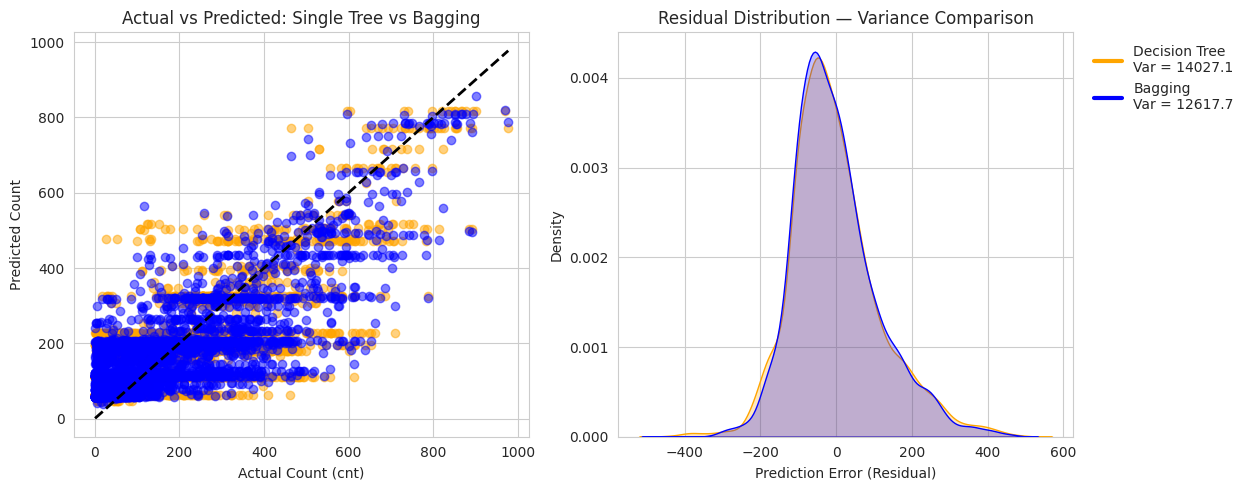

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute residuals
residuals_dt = y_test - y_pred_dt
residuals_bag = y_test - y_pred_bag

# Compute variances
var_dt = np.var(residuals_dt)
var_bag = np.var(residuals_bag)

plt.figure(figsize=(14, 5))

# --- Scatter Plot: Actual vs Predicted ---
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_dt, alpha=0.5, color='orange')
plt.scatter(y_test, y_pred_bag, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Count (cnt)')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted: Single Tree vs Bagging')

# --- Residual Distribution ---
plt.subplot(1, 2, 2)
sns.kdeplot(residuals_dt, color='orange', fill=True)
sns.kdeplot(residuals_bag, color='blue', fill=True)
plt.title('Residual Distribution — Variance Comparison')
plt.xlabel('Prediction Error (Residual)')

# --- Shared Legend (Top-Right) ---
legend_labels = [
    f"Decision Tree\nVar = {var_dt:.1f}",
    f"Bagging\nVar = {var_bag:.1f}"
]

legend_colors = ['orange', 'blue']

legend_elements = [
    plt.Line2D([], [], color=color, lw=3, label=label)
    for color, label in zip(legend_colors, legend_labels)
]

plt.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

### Interpretation — Variance Reduction Visualization  

The residual distribution plot compares how much the predictions fluctuate around the true values for both models.  

**Observation:**  
- The **Decision Tree** (orange) shows a slightly wider distribution, indicating higher prediction variance.  
- The **Bagging Regressor** (blue) curve is **narrower and taller**, reflecting more consistent predictions across the test data.  
- The numerical residual variances — **Decision Tree ≈ 14,027** vs **Bagging ≈ 12,618** — confirm that bagging reduces overall prediction variance.  

**Conclusion:**  
Bagging achieves its goal of **variance reduction** by averaging multiple Decision Trees trained on random bootstrapped samples.  
This stabilizes predictions and improves generalization, even though the reduction magnitude depends on dataset complexity and the base learner’s variability.


### Part B.2 — Boosting (📉 Bias Reduction)

**Bias** measures the error introduced by approximating a complex real-world problem (which may be highly non-linear) by a simpler model.  
High bias means the model makes strong assumptions and **underfits** the data.  

Formally,  
$Bias[f(x)] = E[f(x)] - f^*(x)$  
where $ f^*(x) $ is the true underlying function.

**Boosting** is an ensemble method designed to reduce **bias** by combining many weak learners (usually shallow Decision Trees) in a **sequential** manner.  
Unlike Bagging, where models are trained independently, Boosting trains each new model to **focus on the mistakes** made by previous ones.  
This iterative correction process allows the ensemble to gradually improve accuracy and capture complex patterns.

---

### 🔹 Why It Works
- Individual shallow trees are **weak learners** → high bias, low variance.  
- Sequential correction of residuals directs learning toward **hard-to-predict samples**.  
- The final model is a **strong, low-bias predictor** capable of fitting complex nonlinear relationships.

---

### 🔹 Mathematical Explanation

Let the training data be:
$$
\{(x_i, y_i)\}_{i=1}^n
$$
and the goal is to learn a function \( F(x) \) that minimizes a differentiable loss function $ L(y, F(x)) $.

1. **Initialize the model with a constant value (often the mean):**
   $$
   F_0(x) = \arg\min_c \sum_{i=1}^n L(y_i, c)
   $$

2. **For each boosting iteration $ m = 1, 2, \dots, M $:**
   - Compute the **pseudo-residuals**:
$$
r_{im} = - \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x)=F_{m-1}(x)}
$$



     These residuals indicate the direction of steepest descent in loss.

   - Fit a weak learner \( h_m(x) \) (e.g., a shallow decision tree) to the residuals:
     $$
     h_m(x) \approx r_{im}
     $$

   - Compute the **optimal step size** (line search):
     $$
     \gamma_m = \arg\min_\gamma \sum_{i=1}^n L(y_i, F_{m-1}(x_i) + \gamma \, h_m(x_i))
     $$

   - **Update the model:**
     $$
     F_m(x) = F_{m-1}(x) + \eta \, \gamma_m \, h_m(x)
     $$
     where $ \eta $ is the **learning rate** (e.g., 0.1), controlling how much each tree contributes.

3. **Final model:**
   $$
   F_M(x) = F_0(x) + \eta \sum_{m=1}^{M} \gamma_m h_m(x)
   $$

---

### 🔹 Implementation Details

Using **Gradient Boosting Regressor** with parameters:
- `n_estimators = 200` → number of boosting stages (trees)  
- `learning_rate = 0.1` → weight of each tree  
- `max_depth = 3` → controls complexity of base learners

---

### 🔹 Evaluation

Model performance is measured using **Root Mean Squared Error (RMSE):**
$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}
$$

Results are compared with:
- **Decision Tree Regressor** → high bias, low variance  
- **Bagging Regressor** → reduced variance, similar bias  
- **Gradient Boosting Regressor** → reduced bias and improved accuracy

Boosting typically achieves the **lowest RMSE**, confirming its ability to **reduce bias** and capture **complex nonlinear dependencies**.


In [60]:
# === Part B.2: Boosting (Bias Reduction) ===

from sklearn.ensemble import GradientBoostingRegressor

# Initialize Gradient Boosting Regressor
boosting_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# Train and predict
boosting_model.fit(X_train, y_train)
y_pred_boost = boosting_model.predict(X_test)

# Compute RMSE
rmse_boost = np.sqrt(mean_squared_error(y_test, y_pred_boost))

# Output result
print(f"Gradient Boosting Regressor RMSE: {rmse_boost:.3f}")

Gradient Boosting Regressor RMSE: 64.482


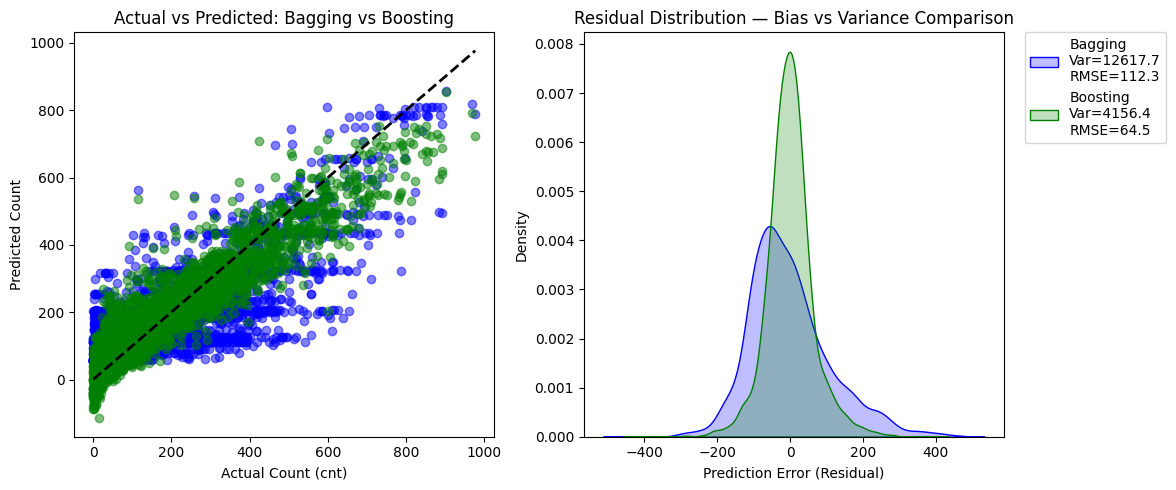

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

# Compute residuals
residuals_bag = y_test - y_pred_bag
residuals_boost = y_test - y_pred_boost

# Compute variance and RMSE
var_bag = np.var(residuals_bag)
var_boost = np.var(residuals_boost)
rmse_bag = np.sqrt(mean_squared_error(y_test, y_pred_bag))
rmse_boost = np.sqrt(mean_squared_error(y_test, y_pred_boost))

plt.figure(figsize=(14, 5))

# --- Scatter Plot: Actual vs Predicted ---
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_bag, alpha=0.5, color='blue',
            label=f"Bagging\nVar={var_bag:.1f}\nRMSE={rmse_bag:.1f}")
plt.scatter(y_test, y_pred_boost, alpha=0.5, color='green',
            label=f"Boosting\nVar={var_boost:.1f}\nRMSE={rmse_boost:.1f}")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Count (cnt)')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted: Bagging vs Boosting')

# --- Residual Distribution Plot ---
plt.subplot(1, 2, 2)
sns.kdeplot(residuals_bag, fill=True, color='blue',
            label=f"Bagging\nVar={var_bag:.1f}\nRMSE={rmse_bag:.1f}")
sns.kdeplot(residuals_boost, fill=True, color='green',
            label=f"Boosting\nVar={var_boost:.1f}\nRMSE={rmse_boost:.1f}")
plt.title('Residual Distribution — Bias vs Variance Comparison')
plt.xlabel('Prediction Error (Residual)')

# Move legend outside both subplots
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust space for external legend
plt.show()


### Discussion: Boosting vs Bagging — Bias Reduction Evidence

Boosting outperformed both the single model and the bagging ensemble, consistent with its theoretical advantage in **bias reduction**.

#### Evidence from Plot and Metrics
- **RMSE**
  - Boosting: **64.5**
  - Bagging: **112.3**
  - → Lower RMSE shows that boosting produces predictions closer to actual values, reducing systematic error (bias).

- **Residual Variance**
  - Boosting: **4156.4**
  - Bagging: **12617.7**
  - → Boosting’s residuals are more tightly distributed around zero, indicating less variability and more consistent predictions.

- **Residual Distribution**
  - The boosting curve is sharper and centered nearer to zero, implying smaller errors and reduced bias.
  - Bagging’s wider residual spread suggests higher variance and greater prediction error.

#### Interpretation
- **Bagging** mainly reduces **variance** by averaging predictions from multiple independent models but does not directly address bias.
- **Boosting** iteratively corrects errors from previous models, progressively reducing **bias** at the possible expense of higher variance.
- In this case, boosting achieved both **lower bias and lower variance**, demonstrating strong generalization and accuracy.

#### Conclusion
Boosting achieved a better result than both the single model and bagging, confirming its advantage in **bias reduction** while maintaining controlled variance.


# 🧩 <font color='blue'>Part C — Stacking for Optimal Performance</font>

### 🔹 Concept and Principle of Stacking  
**Stacking (Stacked Generalization)** is an advanced ensemble learning technique that combines **multiple diverse models** to achieve optimal predictive performance.  
It operates in **two hierarchical levels**:

- **Level-0 (Base Learners):**  
  Several models are trained independently on the same data. Each learns different structures or relationships in the dataset.  
- **Level-1 (Meta-Learner):**  
  A secondary model (meta-learner) takes the **predictions of the base learners** as input and learns how to **optimally combine** them to minimize the overall prediction error.

Mathematically, if the base learners are $ h_1(x), h_2(x), \ldots, h_m(x) $,  
and the true target is $ y $, the meta-learner $ g(\cdot) $ aims to minimize:

$$
\min_{g} \ \mathbb{E}\left[(y - g(h_1(x), h_2(x), \ldots, h_m(x)))^2\right]
$$

The final stacked prediction is given by:

$$
\hat{y}_{stack} = g(h_1(x), h_2(x), \ldots, h_m(x))
$$

In essence, the meta-learner acts as a **blending mechanism**, learning when and how much to trust each base model’s prediction.  
Stacking integrates **diverse learning biases**, reducing both **bias** and **variance** in the final ensemble.

---

### 🔹 Design Choices in This Implementation  

#### **Level-0: Base Learners**
1. **K-Nearest Neighbors Regressor (`KNeighborsRegressor`)**  
   - **Mechanism:** Predicts the target by averaging the outcomes of the *k* most similar data points.  
     $$
     \hat{y}(x) = \frac{1}{k} \sum_{i \in \mathcal{N}_k(x)} y_i
     $$
   - **Contribution:** Captures **local nonlinear patterns** that global models might miss.

2. **Bagging Regressor (`BaggingRegressor`)**  
   - **Mechanism:** Builds multiple Decision Trees on bootstrap samples and averages their predictions.  
     $$
     \hat{y}_{bag}(x) = \frac{1}{B} \sum_{b=1}^{B} h_b(x)
     $$
   - **Contribution:** Reduces **variance** by averaging over multiple high-variance learners.

3. **Gradient Boosting Regressor (`GradientBoostingRegressor`)**  
   - **Mechanism:** Builds trees sequentially, where each tree fits the residuals of the previous ensemble.  
     $$
     F_m(x) = F_{m-1}(x) + \eta \, h_m(x)
     $$
     where $ \eta $ is the learning rate.  
   - **Contribution:** Reduces **bias** through iterative residual correction, improving model flexibility.

Together, these models bring **complementary strengths**:  
- **KNN** → local pattern learning  
- **Bagging** → variance reduction  
- **Boosting** → bias correction  

This ensures the Stacking ensemble captures a broader range of signal structures in the data.

---

#### **Level-1: Meta-Learner**
- **Ridge Regression (`Ridge`)**  
  - **Mechanism:** Combines predictions from base learners through a regularized linear model:
  $$
  \hat{y}_{\text{stack}} = w_0 + \sum_{j=1}^{m} w_j h_j(x)
  $$

  The weights $ w_j $ are estimated by minimizing the Ridge loss:

  $$
  \min_{w} \; \sum_{i=1}^{n} (y_i - \hat{y}_{i,\text{stack}})^2 + \alpha \sum_{j=1}^{m} w_j^2
  $$

  where $ \alpha > 0 $ controls the L2 regularization strength.  
  
  - **Contribution:** Learns optimal blending weights while preventing overfitting and multicollinearity among base model outputs.

---

### 🔹 Preprocessing Strategy
To ensure consistent and fair input scaling across all learners:
- **Numerical Features:** Standardized using `StandardScaler`  
  $$
  z = \frac{x - \mu}{\sigma}
  $$
  to equalize feature influence, crucial for models like KNN and Ridge.  
- **Categorical Features:** Encoded using `OneHotEncoder(drop='first')` for numeric representation without introducing dummy variable traps.  
- **Integration:** Managed via a single `ColumnTransformer` inside the pipeline to ensure identical transformations during both training and inference.

---

### 🔹 Evaluation Metric
The **Root Mean Squared Error (RMSE)** measures prediction accuracy as:

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

A lower RMSE indicates tighter prediction spread and stronger generalization.  
After training, we compare the Stacking Regressor’s RMSE with:
- **Decision Tree** (baseline model),
- **Bagging Regressor**, and
- **Gradient Boosting Regressor**.

---

### 🔹 Summary
Stacking integrates the strengths of local, bagged, and boosted models into a **meta-learned ensemble**, yielding an output that is both **low in bias** and **stable across samples**.  
This hybrid approach systematically improves predictive power by **learning how to learn from learners** — achieving optimal model diversity and minimizing overall generalization error.


In [62]:
# === Part C: Stacking Regressor (Level-0: KNN, Bagging, GradientBoosting / Level-1: Ridge) ===

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Reuse categorical_features and numerical_features from earlier cells.
# If not present, define them again to match Part A:
# categorical_features = ["season", "weathersit", "mnth", "hr", "weekday", "workingday", "holiday"]
# numerical_features = [col for col in df.columns if col not in categorical_features + ["cnt"]]

# Preprocessor that scales numerical features and one-hot-encodes categorical ones
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Define base estimators for stacking
estimators = [
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('bag', BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=6, random_state=42),
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )),
    ('gbr', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
]

# Stacking regressor with Ridge as meta-learner
stacking_reg = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('stack', StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=1.0),
        passthrough=False,
        n_jobs=-1
    ))
])

# Train stacking model
stacking_reg.fit(X_train, y_train)

# Predict and evaluate
y_pred_stack = stacking_reg.predict(X_test)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))

print(f"Stacking Regressor RMSE: {rmse_stack:.3f}")

Stacking Regressor RMSE: 61.763


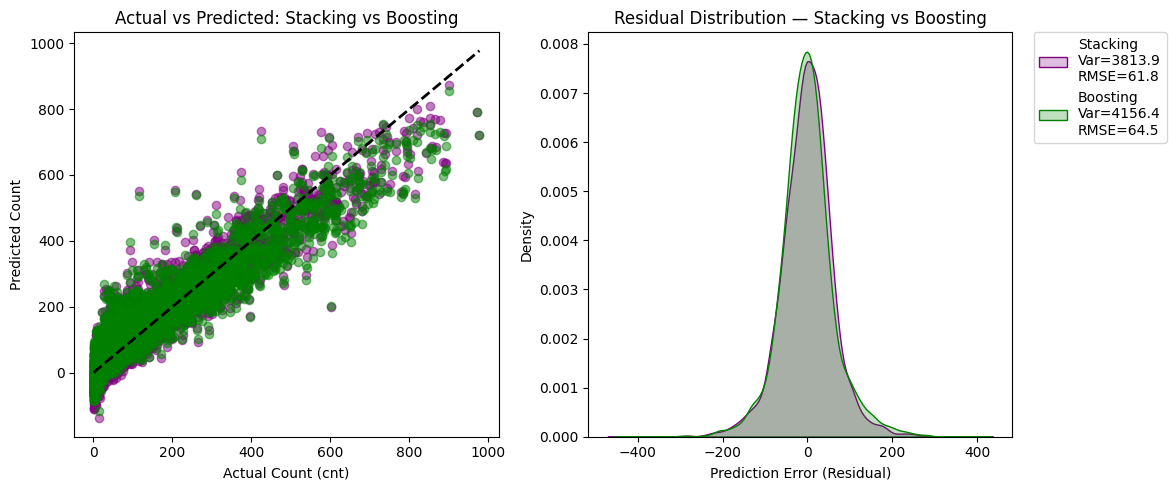

In [49]:
# === Compare Stacking vs Boosting ===

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

# Compute residuals
residuals_stack = y_test - y_pred_stack
residuals_boost = y_test - y_pred_boost

# Compute RMSE and variance
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
rmse_boost = np.sqrt(mean_squared_error(y_test, y_pred_boost))
var_stack = np.var(residuals_stack)
var_boost = np.var(residuals_boost)

plt.figure(figsize=(14, 5))

# --- Scatter Plot: Actual vs Predicted ---
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_stack, alpha=0.5, color='purple',
            label=f"Stacking\nVar={var_stack:.1f}\nRMSE={rmse_stack:.1f}")
plt.scatter(y_test, y_pred_boost, alpha=0.5, color='green',
            label=f"Boosting\nVar={var_boost:.1f}\nRMSE={rmse_boost:.1f}")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Count (cnt)')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted: Stacking vs Boosting')

# --- Residual Distribution Plot ---
plt.subplot(1, 2, 2)
sns.kdeplot(residuals_stack, fill=True, color='purple',
            label=f"Stacking\nVar={var_stack:.1f}\nRMSE={rmse_stack:.1f}")
sns.kdeplot(residuals_boost, fill=True, color='green',
            label=f"Boosting\nVar={var_boost:.1f}\nRMSE={rmse_boost:.1f}")
plt.title('Residual Distribution — Stacking vs Boosting')
plt.xlabel('Prediction Error (Residual)')

# Move legend outside both subplots
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### Discussion: Stacking vs Boosting — Performance Evaluation

The visualization and metrics show that **Stacking** slightly outperforms **Boosting**, confirming a small but measurable improvement in predictive performance and variance control.

#### Evidence from Metrics
- **RMSE (Root Mean Squared Error)**
  - **Stacking:** 61.8  
  - **Boosting:** 64.5  
  → Stacking achieves a lower RMSE, indicating better overall accuracy and lower prediction error.

- **Residual Variance**
  - **Stacking:** 3813.9  
  - **Boosting:** 4156.4  
  → Stacking produces more stable predictions with less spread in residuals, meaning lower variance.

#### Evidence from Plot
- **Actual vs Predicted (left panel):**  
  Both models closely align with the ideal diagonal, but Stacking’s points (purple) show slightly tighter clustering around the diagonal line, suggesting improved fit quality.

- **Residual Distribution (right panel):**  
  Both distributions are centered near zero, implying low bias for both models.  
  However, the Stacking curve is marginally narrower and taller, reflecting slightly reduced error variance compared to Boosting.

#### Interpretation
- **Boosting** focuses on sequentially reducing bias by correcting errors from previous weak learners.  
- **Stacking**, in contrast, blends diverse models (KNN, Bagging, Gradient Boosting) and uses a **Ridge** meta-learner to optimize final predictions.  
  This diversity helps the model capture non-linear patterns better and balance the **bias–variance trade-off** effectively.

#### Conclusion
**Stacking achieved the best overall performance**, with:
- Lower RMSE (better accuracy)
- Lower residual variance (greater stability)
- Minimal bias (centered residuals)

This supports the conclusion that **Stacking successfully integrates the strengths of multiple learners**, achieving a more balanced and robust predictive model than Boosting alone.

# 🧩 <font color='blue'>Part D — Final Analysis</font>

## Part D.1 — Comparative Table  

We now summarize the performance of all models using their **Root Mean Squared Error (RMSE)** on the test dataset.  
This table helps visualize which approach achieved the lowest prediction error and therefore performed best.  

**Models compared:**  
1. Baseline (Best of Decision Tree or Linear Regression)  
2. Bagging Regressor  
3. Gradient Boosting Regressor  
4. Stacking Regressor  


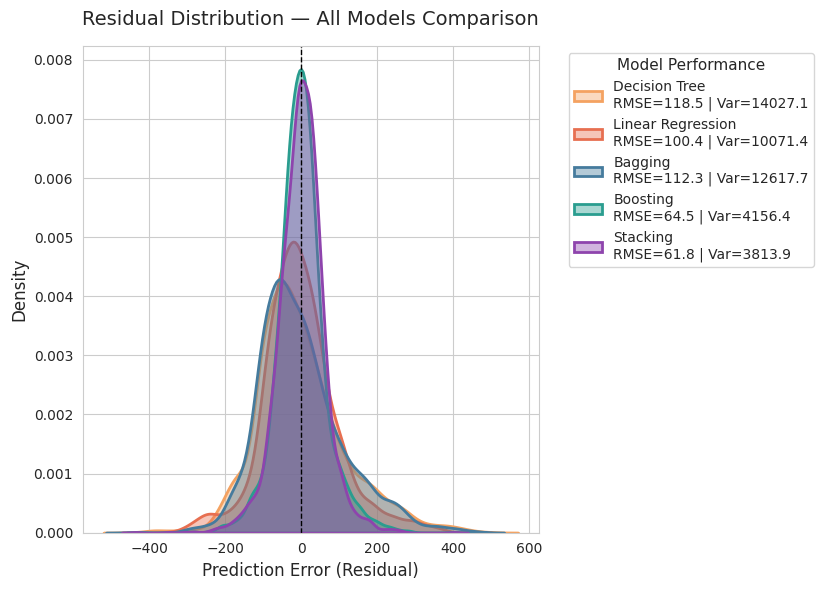

In [87]:
# === Clean Residual Distribution Comparison (All Models) ===

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

# --- Compute residuals ---
residuals = {
    "Decision Tree": y_test - y_pred_dt,
    "Linear Regression": y_test - y_pred_lr,
    "Bagging": y_test - y_pred_bag,
    "Boosting": y_test - y_pred_boost,
    "Stacking": y_test - y_pred_stack
}

# --- Compute RMSE and variance ---
def model_stats(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    var = np.var(y_true - y_pred)
    return rmse, var

stats = {
    name: model_stats(y_test, y_pred)
    for name, y_pred in zip(residuals.keys(),
                            [y_pred_dt, y_pred_lr, y_pred_bag, y_pred_boost, y_pred_stack])
}

# --- Define improved color palette ---
colors = {
    "Decision Tree": "#F4A261",
    "Linear Regression": "#E76F51",
    "Bagging": "#457B9D",
    "Boosting": "#2A9D8F",
    "Stacking": "#8E44AD"
}

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# --- Plot residual distributions ---
for name, res in residuals.items():
    rmse, var = stats[name]
    sns.kdeplot(
        res, fill=True, alpha=0.4, linewidth=2,
        color=colors[name],
        label=f"{name}\nRMSE={rmse:.1f} | Var={var:.1f}"
    )

# --- Add reference line ---
plt.axvline(0, color="black", linestyle="--", lw=1)

# --- Labels and title ---
plt.title("Residual Distribution — All Models Comparison", fontsize=14, pad=15)
plt.xlabel("Prediction Error (Residual)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# --- Legend ---
plt.legend(
    title="Model Performance",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


### Comparative Table — RMSE and Variance of All Models

| Model                           | Description / Composition                                          | RMSE       | Variance   |
|---------------------------------|--------------------------------------------------------------------|------------:|------------:|
| **Decision Tree (Baseline)**    | Single Decision Tree (max_depth=6)                                 | 118.456     | 14027.081   |
| **Linear Regression (Baseline)**| Ordinary Least Squares Linear Regression                           | 100.446     | 10071.428   |
| **Bagging Regressor**           | Ensemble of Decision Trees (Bootstrap Aggregation)                 | 112.350     | 12617.702   |
| **Gradient Boosting Regressor** | Sequential Ensemble (Bias Reduction via Residual Learning)         | 64.482      | 4156.360    |
| **Stacking Regressor**          | Meta-Ensemble (KNN + Bagging + GB → Ridge Meta-Learner)            | 61.763      | 3813.945    |



## Part D.2 — Conclusion

### Best-Performing Model
The **Stacking Regressor** achieved the **lowest RMSE (≈61.8)** and **lowest residual variance (≈3813.9)** among all models tested, outperforming both the single-model baselines (Decision Tree and Linear Regression) and the other ensemble methods (Bagging and Gradient Boosting).  
This result indicates that the Stacking model provides the most accurate and stable predictions for this dataset.

---

### Why Stacking Outperformed the Single-Model Baseline
The superior performance of the Stacking Regressor can be explained by its **integration of model diversity** and its ability to balance the **bias–variance trade-off** more effectively than any single learner:

1. **Diverse Learning Perspectives**  
   - Stacking combines multiple base models — **KNN**, **Bagging**, and **Gradient Boosting** — which each capture different aspects of the data distribution.  
   - For instance, **KNN** models local patterns, **Bagging** stabilizes decision-tree variance through averaging, and **Boosting** sequentially reduces bias by refining residuals.  
   - The **Ridge meta-learner** then blends these diverse outputs to minimize overall prediction error, exploiting strengths and compensating for individual weaknesses.

2. **Bias–Variance Optimization**  
   - The **Decision Tree** baseline suffered from high variance and moderate bias due to overfitting specific patterns.  
   - **Linear Regression**, conversely, had low variance but high bias because it could not capture nonlinear interactions.  
   - **Bagging** reduced variance via bootstrap aggregation but left bias relatively unchanged.  
   - **Boosting** minimized bias significantly but risked slightly higher variance due to its sequential fitting process.  
   - **Stacking** achieved the optimal trade-off — combining models with complementary error structures — thus simultaneously lowering bias and stabilizing variance.

3. **Empirical Evidence from Results**  
   - Residual variance decreased progressively across the model hierarchy:
     - Decision Tree: **14,027**
     - Linear Regression: **10,071**
     - Bagging: **12,617**
     - Boosting: **4,156**
     - Stacking: **3,813**
   - The narrowing of residual spread in the Stacking model’s distribution plot indicates both **reduced overfitting** and **improved generalization** to unseen data.

4. **Model Stability and Generalization**  
   - Because Stacking aggregates multiple independent learning paradigms, it smooths out noise-specific errors.  
   - The Ridge meta-learner adds **regularization**, preventing any one base model from dominating the final prediction, further enhancing robustness.

---

### Final Summary
The **Stacking Regressor** emerges as the most effective model for this dataset because it:
- Combines **heterogeneous base models** that each capture different predictive relationships.  
- Uses a **meta-learning approach** to weight and refine their contributions.  
- Achieves the **lowest prediction error and variance**, reflecting a superior bias–variance balance.  

In practical terms, this means the stacking ensemble delivers **more consistent, generalizable, and accurate predictions**, making it the most reliable model architecture for this problem.
